# Compute preferred number for each number coding neuron (160/554)

In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.firing_rate_tuning import analyze_neuron
import src.number_decoding_analysis as nda

importlib.reload(nda)

TABLES = ROOT / "tables1"
FIGURES = ROOT / "figures1"

FIGURES.mkdir(exist_ok=True)

In [2]:
perm = pd.read_csv(
    TABLES / "figure1M_all_neuron_permutations.csv"
)

print(perm.columns.tolist())
print(perm.shape)

coding = perm[
    perm["TC_coding"].astype(bool)
].copy()

print("TC-coding neurons:", len(coding))

display(coding.head())

['subject', 'neuron', 'region', 'FR_accuracy', 'TC_accuracy', 'best_bin_ms', 'best_gamma', 'n_presentations', 'n_splits', 'FR_null_mean', 'FR_p', 'FR_coding', 'TC_null_mean', 'TC_p', 'TC_coding', 'elapsed_seconds']
(552, 16)
TC-coding neurons: 160


,subject,neuron,region,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,n_presentations,n_splits,FR_null_mean,FR_p,FR_coding,TC_null_mean,TC_p,TC_coding,elapsed_seconds
2,YFF,11,hpc,0.110092,0.201835,100,0.5,109,7,0.109404,0.532338,False,0.107248,0.019900,True,10.417088
3,YFF,12,hpc,0.100917,0.174312,300,0.5,109,7,0.110459,0.641791,False,0.108165,0.049751,True,11.636312
5,YFF,14,hpc,0.119266,0.192661,100,0.2,109,7,0.108440,0.422886,False,0.108532,0.029851,True,11.401566
11,YFF,29,hpc,0.091743,0.183486,180,0.2,109,7,0.105046,0.691542,False,0.109037,0.034826,True,10.891408
13,YFF,31,hpc,0.091743,0.192661,100,0.5,109,7,0.108119,0.726368,False,0.109725,0.024876,True,11.551045


In [3]:
results = []

for k, row in coding.reset_index(drop=True).iterrows():

    subject = row["subject"]
    neuron = int(row["neuron"])

    print(
        f"[{k+1}/{len(coding)}] "
        f"{subject} neuron {neuron}"
    )

    # -----------------------------------------------
    # Load this neuron's presentations and spikes
    # -----------------------------------------------

    out = analyze_neuron(
        subject,
        neuron,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    presentations = out["presentations"]
    spike_times = out["spike_times"]

    # -----------------------------------------------
    # Use the temporal parameters already selected
    # during Figure 1N
    # -----------------------------------------------

    bin_size = int(row["best_bin_ms"])
    gamma = float(row["best_gamma"])

    X, y, edges = nda.make_temporal_features(
        presentations,
        spike_times,
        bin_size=bin_size,
        window_start=50,
        window_end=950,
    )

    # Same fold rule as before
    _, counts = np.unique(y, return_counts=True)

    n_splits = min(
        10,
        int(counts.min())
    )

    # -----------------------------------------------
    # Cross-validated predictions
    # -----------------------------------------------

    (
        overall_acc,
        per_number_acc,
        y_true,
        y_pred,
    ) = nda.cv_lda_per_number_accuracy(
        X,
        y,
        gamma=gamma,
        n_splits=n_splits,
        random_state=42,
    )

    # -----------------------------------------------
    # Preferred number
    #
    # Paper definition:
    # number with highest decoding accuracy
    # -----------------------------------------------

    accuracies = np.array(
        [per_number_acc[n] for n in range(1, 10)]
    )

    preferred_number = int(
        np.nanargmax(accuracies) + 1
    )

    result = {
        "subject": subject,
        "neuron": neuron,
        "best_bin_ms": bin_size,
        "best_gamma": gamma,
        "overall_accuracy": overall_acc,
        "preferred_number": preferred_number,
    }

    for number in range(1, 10):
        result[f"accuracy_{number}"] = per_number_acc[number]

    results.append(result)


preferred = pd.DataFrame(results)

display(preferred.head())

print("\nPreferred-number counts:")
print(
    preferred["preferred_number"]
    .value_counts()
    .sort_index()
)

[1/160] YFF neuron 11
[2/160] YFF neuron 12
[3/160] YFF neuron 14
[4/160] YFF neuron 29
[5/160] YFF neuron 31
[6/160] YFF neuron 34
[7/160] YFF neuron 35
[8/160] YFF neuron 39
[9/160] YFF neuron 40
[10/160] YFF neuron 41
[11/160] YFF neuron 51
[12/160] YFI neuron 2
[13/160] YFI neuron 3
[14/160] YFI neuron 4
[15/160] YFI neuron 8
[16/160] YFI neuron 21
[17/160] YFI neuron 24
[18/160] YFI neuron 26
[19/160] YFI neuron 30
[20/160] YFI neuron 31
[21/160] YFI neuron 35
[22/160] YFJ neuron 10
[23/160] YFJ neuron 12
[24/160] YFJ neuron 20
[25/160] YFJ neuron 22
[26/160] YFJ neuron 23
[27/160] YFJ neuron 26
[28/160] YFJ neuron 29
[29/160] YFJ neuron 43
[30/160] YFJ neuron 44
[31/160] YFJ neuron 45
[32/160] YFJ neuron 50
[33/160] YFJ neuron 55
[34/160] YFJ neuron 58
[35/160] YFJ neuron 61
[36/160] YFJ neuron 62
[37/160] YFK neuron 25
[38/160] YFK neuron 27
[39/160] YFK neuron 29
[40/160] YFK neuron 30
[41/160] YFK neuron 31
[42/160] YFK neuron 32
[43/160] YFK neuron 37
[44/160] YFK neuron 40
[

,subject,neuron,best_bin_ms,best_gamma,overall_accuracy,preferred_number,accuracy_1,accuracy_2,accuracy_3,accuracy_4,accuracy_5,accuracy_6,accuracy_7,accuracy_8,accuracy_9
0,YFF,11,100,0.5,0.201835,6,0.1,0.266667,0.181818,0.142857,0.000000,0.3125,0.176471,0.250000,0.214286
1,YFF,12,300,0.5,0.174312,6,0.1,0.133333,0.272727,0.000000,0.000000,0.3125,0.176471,0.250000,0.142857
2,YFF,14,100,0.2,0.192661,3,0.2,0.133333,0.545455,0.000000,0.142857,0.1875,0.294118,0.000000,0.142857
3,YFF,29,180,0.2,0.183486,7,0.1,0.200000,0.272727,0.285714,0.000000,0.2500,0.294118,0.166667,0.000000
4,YFF,31,100,0.5,0.192661,1,0.4,0.066667,0.000000,0.285714,0.285714,0.1250,0.294118,0.166667,0.214286



Preferred-number counts:
preferred_number
1    28
2    25
3    21
4    18
5    16
6     6
7    13
8    14
9    19
Name: count, dtype: int64


In [4]:
preferred

,subject,neuron,best_bin_ms,best_gamma,overall_accuracy,preferred_number,accuracy_1,accuracy_2,accuracy_3,accuracy_4,accuracy_5,accuracy_6,accuracy_7,accuracy_8,accuracy_9
0,YFF,11,100,0.5,0.201835,6,0.100000,0.266667,0.181818,0.142857,0.000000,0.312500,0.176471,0.250000,0.214286
1,YFF,12,300,0.5,0.174312,6,0.100000,0.133333,0.272727,0.000000,0.000000,0.312500,0.176471,0.250000,0.142857
2,YFF,14,100,0.2,0.192661,3,0.200000,0.133333,0.545455,0.000000,0.142857,0.187500,0.294118,0.000000,0.142857
3,YFF,29,180,0.2,0.183486,7,0.100000,0.200000,0.272727,0.285714,0.000000,0.250000,0.294118,0.166667,0.000000
4,YFF,31,100,0.5,0.192661,1,0.400000,0.066667,0.000000,0.285714,0.285714,0.125000,0.294118,0.166667,0.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,YFU,62,150,0.2,0.149798,9,0.245283,0.089552,0.192308,0.258065,0.000000,0.145833,0.107692,0.000000,0.319149
156,YFU,63,180,0.5,0.139676,5,0.226415,0.089552,0.019231,0.241935,0.313725,0.000000,0.030769,0.183673,0.170213
157,YFU,66,450,0.8,0.137652,4,0.018868,0.014925,0.000000,0.419355,0.058824,0.104167,0.261538,0.020408,0.297872
158,YFU,69,60,0.2,0.141700,9,0.226415,0.119403,0.134615,0.145161,0.117647,0.145833,0.030769,0.163265,0.234043


In [5]:
preferred.to_csv(
    TABLES / "figure1S_neuron_preferred_numbers.csv",
    index=False,
)

print(
    "Saved:",
    TABLES / "figure1S_neuron_preferred_numbers.csv"
)

Saved: c:\Users\shafi\number-simplex-reproduction\tables1\figure1S_neuron_preferred_numbers.csv


In [6]:
subjects = sorted(
    preferred["subject"].unique()
)

numbers = np.arange(1, 10)

subject_rows = []

for subject in subjects:

    sub = preferred[
        preferred["subject"] == subject
    ]

    n_coding = len(sub)

    for number in numbers:

        count = np.sum(
            sub["preferred_number"] == number
        )

        percent = (
            100 * count / n_coding
        )

        subject_rows.append({
            "subject": subject,
            "number": number,
            "n_coding_neurons": n_coding,
            "n_preferred": count,
            "percent_preferred": percent,
        })


subject_distribution = pd.DataFrame(
    subject_rows
)

display(subject_distribution.head(18))

,subject,number,n_coding_neurons,n_preferred,percent_preferred
0,YFF,1,11,1,9.090909
1,YFF,2,11,0,0.000000
2,YFF,3,11,2,18.181818
3,YFF,4,11,1,9.090909
4,YFF,5,11,1,9.090909
5,YFF,6,11,2,18.181818
6,YFF,7,11,4,36.363636
7,YFF,8,11,0,0.000000
8,YFF,9,11,0,0.000000
9,YFI,1,10,1,10.000000


In [9]:
display(subject_distribution)

,subject,number,n_coding_neurons,n_preferred,percent_preferred
0,YFF,1,11,1,9.090909
1,YFF,2,11,0,0.000000
2,YFF,3,11,2,18.181818
3,YFF,4,11,1,9.090909
4,YFF,5,11,1,9.090909
...,...,...,...,...,...
94,YFU,5,25,4,16.000000
95,YFU,6,25,1,4.000000
96,YFU,7,25,1,4.000000
97,YFU,8,25,0,0.000000


In [10]:
# ============================================================
# CHECK FOR TIES IN MOST-PREFERRED NUMBER
# ============================================================

import numpy as np
import pandas as pd

numbers = np.arange(1, 10)

tie_rows = []

for _, row in preferred.iterrows():

    # Per-number decoding accuracies for this neuron
    accuracies = np.array(
        [row[f"accuracy_{n}"] for n in numbers],
        dtype=float
    )

    # Highest decoding accuracy
    max_accuracy = np.nanmax(accuracies)

    # ALL numbers achieving that maximum
    tied_numbers = numbers[
        np.isclose(
            accuracies,
            max_accuracy,
            rtol=1e-10,
            atol=1e-12
        )
    ]

    # Save only neurons with >1 maximum
    if len(tied_numbers) > 1:

        result = {
            "subject": row["subject"],
            "neuron": int(row["neuron"]),
            "max_accuracy": max_accuracy,
            "n_tied_numbers": len(tied_numbers),
            "tied_numbers": ", ".join(
                map(str, tied_numbers)
            ),
        }

        # Also save all 9 accuracies so we can inspect them
        for n in numbers:
            result[f"accuracy_{n}"] = row[f"accuracy_{n}"]

        tie_rows.append(result)


ties = pd.DataFrame(tie_rows)


print("======================================")
print("PREFERRED-NUMBER TIE CHECK")
print("======================================")

print(f"Total coding neurons: {len(preferred)}")
print(f"Neurons with a tie:  {len(ties)}")
print(
    f"Neurons without tie: "
    f"{len(preferred) - len(ties)}"
)

if len(ties) > 0:

    print("\nTIED NEURONS:")
    display(ties)

else:

    print("\nNo ties found.")

PREFERRED-NUMBER TIE CHECK
Total coding neurons: 160
Neurons with a tie:  3
Neurons without tie: 157

TIED NEURONS:


,subject,neuron,max_accuracy,n_tied_numbers,tied_numbers,accuracy_1,accuracy_2,accuracy_3,accuracy_4,accuracy_5,accuracy_6,accuracy_7,accuracy_8,accuracy_9
0,YFI,3,0.272727,2,"3, 4",0.1,0.090909,0.272727,0.272727,0.111111,0.100,0.2,0.173913,0.111111
1,YFI,24,0.454545,2,"3, 4",0.3,0.000000,0.454545,0.454545,0.111111,0.300,0.1,0.130435,0.000000
2,YFM,66,0.500000,2,"4, 9",0.0,0.176471,0.285714,0.500000,0.142857,0.375,0.1,0.083333,0.500000


In [11]:
ties.to_csv(
    TABLES / "figure1S_preferred_number_ties.csv",
    index=False
)

print(
    "Saved:",
    TABLES / "figure1S_preferred_number_ties.csv"
)

Saved: c:\Users\shafi\number-simplex-reproduction\tables1\figure1S_preferred_number_ties.csv


UNIQUE PREFERRED-NUMBER NEURONS
Original coding neurons: 160
Excluded tied neurons:   3
Included neurons:        157

Included neurons per subject:
subject
YFF    11
YFI     8
YFJ    15
YFK    17
YFL     9
YFM    15
YFP     9
YFR    15
YFS    20
YFT    13
YFU    25
dtype: int64

Percentage sum per subject:
subject
YFF    100.0
YFI    100.0
YFJ    100.0
YFK    100.0
YFL    100.0
YFM    100.0
YFP    100.0
YFR    100.0
YFS    100.0
YFT    100.0
YFU    100.0
Name: percent_preferred, dtype: float64

Mean ± SEM:


,number,mean,std,count,sem
0,1,17.471334,10.554889,11,3.182419
1,2,16.926528,11.456202,11,3.454175
2,3,11.794261,7.885043,11,2.377430
3,4,10.158591,6.490333,11,1.956909
4,5,10.408991,5.799624,11,1.748652
5,6,3.763409,6.349509,11,1.914449
6,7,8.308116,11.471664,11,3.458837
7,8,8.662759,8.853859,11,2.669539
8,9,12.506010,12.208760,11,3.681080


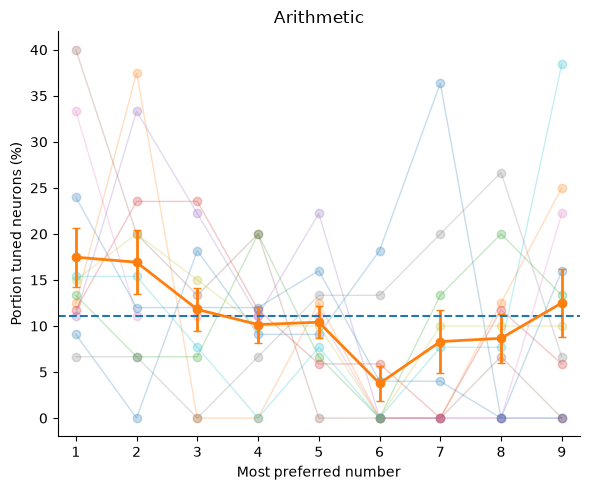


Saved figure:
c:\Users\shafi\number-simplex-reproduction\figures1\figure1S_preferred_numbers_unique_only.png


In [12]:
# ============================================================
# FIGURE 1S
# Preferred-number distribution
#
# IMPORTANT:
# Neurons with tied maximum decoding accuracy are excluded.
# This is OUR reproduction convention because the paper does
# not specify how ties were handled.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


numbers = np.arange(1, 10)

# ------------------------------------------------------------
# 1. ASSIGN PREFERRED NUMBER ONLY IF MAXIMUM IS UNIQUE
# ------------------------------------------------------------

unique_rows = []

for _, row in preferred.iterrows():

    accuracies = np.array(
        [row[f"accuracy_{n}"] for n in numbers],
        dtype=float
    )

    max_accuracy = np.nanmax(accuracies)

    tied_numbers = numbers[
        np.isclose(
            accuracies,
            max_accuracy,
            rtol=1e-10,
            atol=1e-12
        )
    ]

    # Skip neurons whose maximum is tied
    if len(tied_numbers) != 1:
        continue

    unique_rows.append({
        "subject": row["subject"],
        "neuron": int(row["neuron"]),
        "preferred_number": int(tied_numbers[0]),
        "max_accuracy": max_accuracy,
    })


preferred_unique = pd.DataFrame(unique_rows)


print("======================================")
print("UNIQUE PREFERRED-NUMBER NEURONS")
print("======================================")

print("Original coding neurons:", len(preferred))
print("Excluded tied neurons:  ", len(preferred) - len(preferred_unique))
print("Included neurons:       ", len(preferred_unique))


# ------------------------------------------------------------
# 2. NUMBER OF INCLUDED CODING NEURONS PER SUBJECT
# ------------------------------------------------------------

print("\nIncluded neurons per subject:")

print(
    preferred_unique
    .groupby("subject")
    .size()
)


# ------------------------------------------------------------
# 3. SUBJECT-LEVEL PREFERRED-NUMBER DISTRIBUTION
# ------------------------------------------------------------

subject_rows = []

subjects = sorted(
    preferred_unique["subject"].unique()
)

for subject in subjects:

    sub = preferred_unique[
        preferred_unique["subject"] == subject
    ]

    n_neurons = len(sub)

    for number in numbers:

        n_preferred = int(
            np.sum(
                sub["preferred_number"] == number
            )
        )

        percent_preferred = (
            100 * n_preferred / n_neurons
        )

        subject_rows.append({
            "subject": subject,
            "number": number,
            "n_coding_neurons": n_neurons,
            "n_preferred": n_preferred,
            "percent_preferred": percent_preferred,
        })


subject_distribution_unique = pd.DataFrame(
    subject_rows
)


# ------------------------------------------------------------
# 4. CHECK THAT EACH SUBJECT SUMS TO 100%
# ------------------------------------------------------------

check = (
    subject_distribution_unique
    .groupby("subject")["percent_preferred"]
    .sum()
)

print("\nPercentage sum per subject:")
print(check)


# ------------------------------------------------------------
# 5. MEAN AND SEM ACROSS SUBJECTS
# ------------------------------------------------------------

summary_unique = (
    subject_distribution_unique
    .groupby("number")["percent_preferred"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

summary_unique["sem"] = (
    summary_unique["std"] /
    np.sqrt(summary_unique["count"])
)

print("\nMean ± SEM:")
display(summary_unique)


# ------------------------------------------------------------
# 6. SAVE TABLES
# ------------------------------------------------------------

preferred_unique.to_csv(
    TABLES / "figure1S_unique_preferred_neurons.csv",
    index=False
)

subject_distribution_unique.to_csv(
    TABLES / "figure1S_subject_distribution_unique.csv",
    index=False
)

summary_unique.to_csv(
    TABLES / "figure1S_summary_unique.csv",
    index=False
)


# ------------------------------------------------------------
# 7. PLOT FIGURE 1S
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))


# Individual subjects
for subject in subjects:

    sub = (
        subject_distribution_unique[
            subject_distribution_unique["subject"] == subject
        ]
        .sort_values("number")
    )

    ax.plot(
        sub["number"],
        sub["percent_preferred"],
        marker="o",
        linewidth=1,
        alpha=0.25,
    )


# Group mean ± SEM
ax.errorbar(
    summary_unique["number"],
    summary_unique["mean"],
    yerr=summary_unique["sem"],
    marker="o",
    linewidth=2,
    capsize=3,
)


# Chance level = 1 / 9
chance = 100 / 9

ax.axhline(
    chance,
    linestyle="--",
    linewidth=1.5,
)


# ------------------------------------------------------------
# 8. FORMATTING
# ------------------------------------------------------------

ax.set_xticks(numbers)

ax.set_xlabel("Most preferred number")
ax.set_ylabel("Portion tuned neurons (%)")

ax.set_title("Arithmetic")

ax.set_xlim(0.7, 9.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()


# ------------------------------------------------------------
# 9. SAVE FIGURE
# ------------------------------------------------------------

outfile = (
    FIGURES /
    "figure1S_preferred_numbers_unique_only.png"
)

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved figure:")
print(outfile)

In [13]:
# Count neurons preferring each number, across ALL subjects

preferred_counts = (
    preferred_unique["preferred_number"]
    .value_counts()
    .reindex(range(1, 10), fill_value=0)
    .sort_index()
)

print("Preferred-number counts across all subjects:")
print(preferred_counts)

print("\nTotal =", preferred_counts.sum())

Preferred-number counts across all subjects:
preferred_number
1    28
2    25
3    19
4    17
5    16
6     6
7    13
8    14
9    19
Name: count, dtype: int64

Total = 157


In [14]:
100+6

106